# DIFNO inverse operators (SSH -> ice)

Two trained inverse operators, both regularised by cycle consistency through a frozen
forward surrogate: the default one with a plain L1 data loss and PCGrad, the coastal one
with an amplitude-weighted loss and CAGrad.

## 1. Default inverse: cycle consistency + PCGrad

Trains the same tied-weight DSE-FNO in the other direction, from normalised SSH at the
altimetry points to the ice-thickness-change field, on the pooled `single` + `multi`
ensembles (16k train / 4k test). Two losses are combined: a plain L1 data loss and a
cycle-consistency L1 obtained by pushing the predicted ice back through the frozen
default forward surrogate. Their gradients are merged with PCGrad, with the cycle
weight set every batch by gradient-norm balance. Test relative L1 is 21.8% on `single`
and 38.3% on `multi` (30.1% pooled), with 0.68% cycle error.

Source: `cloud_notebooks/no_smooth_512full_cycle_fingerprint_FNO_dse.ipynb`.

In [ ]:
# Model / loss / gradient-surgery definitions live in src/ (they were defined
# inline in the first cells of the original cloud notebooks):
#   src/models.py       VFT (Vandermonde transform), SpectralConv2d_dse, FNO_dse
#   src/losses.py       AmplitudeWeightedLoss
#   src/grad_surgery.py PCGrad / CAGrad
#   src/utilities.py    count_params, percentage_difference (from the DSE repo)
#   src/adam.py         complex-capable Adam (from the DSE repo)
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset

from src import Adam, count_params, percentage_difference, print_params_by_module
from src.device import get_device
from src.models import FNO_dse, set_default_device
from src.grad_surgery import pcgrad_two_task


In [ ]:
from torch.utils.data import TensorDataset
    

def getDataloaders (configs):
    """
    Loads the required data for the Airfoil experiment and returns the train and test dataloaders.

    Returns:
        train_loader (torch.utils.data.DataLoader): train dataloader
        test_loader (torch.utils.data.DataLoader): test dataloader
    """
    paths = [configs['datapath'] + 'no_smooth/512gp_single_SSH_altimetry_full.pt',
             configs['datapath'] + 'no_smooth/512gp_multi_SSH_altimetry_full.pt',
             ]#configs['datapath'] + '512gp_single_sinner_SSH_altimetry_full.pt'
    data_list = [torch.load(path_) for path_ in paths]

    outputs = torch.cat([data_["sample_sum"].float().unsqueeze(-1) for data_ in data_list], dim=0)  # [N_total, 1]
    inputs = torch.cat([data_["altimetry"].float().unsqueeze(-1) for data_ in data_list], dim=0)  # [N_total, M, 1]
    # inputs_mean, input_std = -0.0002, 0.0027
    #normalization
    inputs = (inputs - inputs.mean())/(inputs.std()+1e-6)
    
    
    # path = configs['datapath']+'gp_2_SSH_altimetry_samples_full.pt'

    # data = torch.load(path)
    # inputs = data["altimetry"].float().unsqueeze(-1)
    
    # outputs = data["sample_sum"].float().unsqueeze(-1)
    # outputs = (outputs - outputs.mean())/(outputs.std()+1e-6)#make it worse
    
    #random permutation
    num_total = inputs.shape[0]
    
    g = torch.Generator()
    g.manual_seed(42)
    perm = torch.randperm(10, generator=g)
    indices = torch.randperm(num_total)


    train_indices = indices[:configs['num_train']]
    test_indices = indices[configs['num_train']:configs['num_train'] + configs['num_test']]
    train_in = inputs[train_indices]
    train_out = outputs[train_indices]
    test_in = inputs[test_indices]
    test_out = outputs[test_indices]
    
    # train_in = inputs[:configs['num_train']]
    # train_out = outputs[:configs['num_train']]
    # test_in = inputs[configs['num_train']:configs['num_train']+configs['num_test']]
    # test_out = outputs[configs['num_train']:configs['num_train']+configs['num_test']]
    # # test_in = inputs[-configs['num_test']:]
    # # test_out = outputs[-configs['num_test']:]


    train_loader = torch.utils.data.DataLoader(TensorDataset(train_in, train_out), batch_size=configs['batch_size'], shuffle=True)
    test_loader = torch.utils.data.DataLoader(TensorDataset(test_in, test_out), batch_size=1, shuffle=False)

    point_data_path = configs['datapath']+'512scaled_display_coords_full.pt'
    point_data = torch.load(point_data_path)
    point_data_in = point_data["Dist"].float()
    point_data_out = point_data["Gr"].float()
    
    return train_loader, test_loader, point_data_in, point_data_out
# from torch.utils.data import Dataset, DataLoader, TensorDataset

# class NoisyDataset(Dataset):
#     def __init__(self, inputs, outputs, noise_std=1e-3):
#         self.inputs = inputs
#         self.outputs = outputs
#         self.noise_std = noise_std

#     def __len__(self):
#         return len(self.inputs)

#     def __getitem__(self, idx):
#         x = self.inputs[idx]
#         y = self.outputs[idx]
#         noise = torch.randn_like(x) * self.noise_std
#         x_noisy = x + noise
#         return x_noisy, y


# def getDataloaders(configs):
#     """
#     Loads the required data for the Airfoil experiment and returns the train and test dataloaders.

#     Returns:
#         train_loader (torch.utils.data.DataLoader): train dataloader
#         test_loader (torch.utils.data.DataLoader): test dataloader
#         point_data_in (torch.Tensor): input coordinates
#         point_data_out (torch.Tensor): output ground truth
#     """
#     # Load main data
#     path = configs['datapath'] + 'gp_SL_altimetry_samples_sub.pt'
#     data = torch.load(path)
#     inputs = data["altimetry"].float().unsqueeze(-1)
#     inputs = (inputs - inputs.mean()) / (inputs.std() + 1e-6)  # normalize

#     outputs = data["sample_sum"].float().unsqueeze(-1)
#     # outputs = (outputs - outputs.mean()) / (outputs.std() + 1e-6)  # optional normalization

#     # Split train/test
#     train_in = inputs[:configs['num_train']]
#     train_out = outputs[:configs['num_train']]
#     test_in = inputs[-configs['num_test']:]
#     test_out = outputs[-configs['num_test']:]

#     # Build loaders
#     train_dataset = NoisyDataset(train_in, train_out, noise_std=configs.get('noise_std', 1e-3))
#     train_loader = DataLoader(train_dataset, batch_size=configs['batch_size'], shuffle=True)

#     test_loader = DataLoader(TensorDataset(test_in, test_out), batch_size=1, shuffle=False)

#     # Load point data
#     point_data_path = configs['datapath'] + 'scaled_display_coords.pt'
#     point_data = torch.load(point_data_path)
#     point_data_in = point_data["Dist"].float()
#     point_data_out = point_data["Gr"].float()

#     return train_loader, test_loader, point_data_in, point_data_out


In [ ]:
device = get_device()        # cuda on the cluster, mps/cpu on a laptop
set_default_device(device)   # the VFT matrices are built on this device

forward_model = torch.load(f"_Models/no_smooth_512forward_full.pt",weights_only = False).to(device)
forward_model.eval() 
for param in forward_model.parameters():
    param.requires_grad = False  # freeze parameters


In [ ]:
configs = {
    'save_model':           True,
    'model':                'fno-dse',
    'experiment':           'fingerprint',
    'num_train':            16000,
    'num_test':             4000,
    'batch_size':           400, 
    'epochs':               501,
    'test_epochs':          10,

    'datapath':             "data/",  # Path to data!!!!!

    # Training specific parameters
    'learning_rate':        0.001,
    'scheduler_step':       100,
    'scheduler_gamma':      0.1,
    'weight_decay':         1e-4,                   # Weight decay
    'loss_fn':              'L1',                   # Loss function to use - L1, L2
    'loss_fn_test':         'L1',                   # Loss function to use - L1, L2
    'cycle_weight':         0.1,                    # Weight of cycle consistency loss
    # Model specific parameters
    'modes1':               20,                     # Number of x-modes to use in the Fourier layer
    'modes2':               20,                     # Number of y-modes to use in the Fourier layer
    'width':                32,                     # Number of channels in the convolutional layers
}

Model = FNO_dse
# for key in Model.configs:
#             configs.setdefault(key, Model.configs[key])
# NOTE: Some configs will have been overwritten by the defaults in Model.configs, hence we print here!
print(configs)

start_time = time.time()
print(f'Loading and processing data.')

train_loader, test_loader, configs['point_data_in'],configs['point_data_out'] = getDataloaders(configs)

configs['denormalizer'] = None if not hasattr(train_loader, "denormalizer") else train_loader.denormalizer

print(f'Processing finished in {time.time()-start_time:.2f}s.')


#######
# model
#######
# initialize model
model = Model(configs).to(device)

# TODO: Trainable parameters will now include IPHI parameters as well.
print(f"Number of trainable parameters: {count_params(model)}")
optimizer = Adam(model.parameters(), lr=configs['learning_rate'], weight_decay=configs['weight_decay'])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=configs['scheduler_step'], gamma=configs['scheduler_gamma'])
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max = 30)
# Define the loss function
if configs['loss_fn'] == 'L1':
    loss_fn = torch.nn.L1Loss()
elif configs['loss_fn'] == 'L2':
    loss_fn = torch.nn.MSELoss('mean')
else:
    raise ValueError('Loss function not recognized.')
# Define the loss function
if configs['loss_fn_test'] == 'L1':
    loss_fn_test = torch.nn.L1Loss()
elif configs['loss_fn_test'] == 'L2':
    loss_fn_test = torch.nn.MSELoss('mean')
else:
    raise ValueError('Loss function test not recognized.')
# class L1WithMeanLoss(nn.Module):
#     def __init__(self, mean_weight=1.0):
#         super().__init__()
#         self.l1 = nn.L1Loss()
#         self.mean_weight = mean_weight

#     def forward(self, pred, target):
#         l1_loss = self.l1(pred, target)
#         mean_loss = torch.abs(pred.mean() - target.mean())
#         return l1_loss + self.mean_weight * mean_loss
# if configs['loss_fn'] == 'L1':
#     loss_fn = L1WithMeanLoss(mean_weight=1)


{'save_model': True, 'model': 'fno-dse', 'experiment': 'fingerprint', 'num_train': 16000, 'num_test': 4000, 'batch_size': 400, 'epochs': 501, 'test_epochs': 10, 'datapath': 'data/', 'learning_rate': 0.001, 'scheduler_step': 100, 'scheduler_gamma': 0.1, 'weight_decay': 0.0001, 'loss_fn': 'L1', 'loss_fn_test': 'L1', 'cycle_weight': 0.1, 'modes1': 20, 'modes2': 20, 'width': 32}


Loading and processing data.
Processing finished in 2.61s.
Number of trainable parameters: 21949597


In [ ]:
#PCGrad + weight balance
import torch.autograd as autograd
##########
# training
##########
training_times = []
train_loss_hist = []
test_loss_hist = []
train_cycle_loss_hist = []
relative_error_hist = []
relative_median_error_hist = []
lambda_cycle = configs['cycle_weight']
for epoch in range(configs['epochs']):
    start_train = time.time()
    train_loss = 0
    train_cycle_loss = 0
    model.train()
    for inputs, targets in train_loader:
        batch_size = targets.shape[0]
        if isinstance(inputs, list):
            inputs = [x.to(device) for x in inputs]
        else:
            inputs = inputs.to(device)
        targets = targets.to(device)

        predictions = model(inputs)

        # Compute loss separate for complex numbers
        if predictions.is_complex():
            loss_inv = (
                loss_fn(predictions.real.view(batch_size, -1), targets.real.view(batch_size, -1)) 
                + loss_fn(predictions.imag.view(batch_size, -1), targets.imag.view(batch_size, -1))
            )
        else:
            loss_inv = loss_fn(predictions.view(batch_size, -1), targets.view(batch_size, -1))

        
        # # For diffeomorphisms, additional loss term:
        # if hasattr(model, "model_iphi") and ('iphi_loss_reg' in configs) and (configs['iphi_loss_reg'] > 0):
        #     samples_x = torch.rand(batch_size, targets.shape[1], 2).cuda() * 3 - 1 # TODO Hardcoded values, check if applies to all
        #     samples_xi = model.model_iphi(samples_x)
        #     loss += configs['iphi_loss_reg'] * loss_fn(samples_xi, samples_x)


        train_loss += loss_inv.item()
        
        #cycle consistency loss
        cycle_outputs = forward_model(predictions)
        loss_cycle = loss_fn(cycle_outputs.view(batch_size, -1), inputs.view(batch_size, -1))

        
        train_cycle_loss += loss_cycle.item()
        
        optimizer.zero_grad()

        grads_inv = autograd.grad(loss_inv, model.parameters(), retain_graph=True, allow_unused=True)
        grads_inv = [g if g is not None else torch.zeros_like(p) for g, p in zip(grads_inv, model.parameters())]

        grads_cycle = autograd.grad(loss_cycle, model.parameters(), retain_graph=False, allow_unused=True)
        grads_cycle = [g if g is not None else torch.zeros_like(p) for g, p in zip(grads_cycle, model.parameters())]

        norm_inv = torch.norm(torch.stack([g.norm() for g in grads_inv]))
        norm_cycle = torch.norm(torch.stack([g.norm() for g in grads_cycle]))
        lambda_cycle = (norm_inv / (norm_cycle + 1e-6)).detach()

        # PCGrad projection (moved to src/grad_surgery.py)
        projected_grads = pcgrad_two_task(grads_inv, grads_cycle, lambda_cycle)
                
        # # Weight balancing (automatic)
        # if epoch>=100:
        #     norm_inv = torch.norm(torch.stack([g.norm() for g in grads_inv]))
        #     norm_cycle = torch.norm(torch.stack([g.norm() for g in grads_cycle]))
        #     lambda_cycle = (norm_inv / (norm_cycle + 1e-4)).detach() * 0.1

        #     # PCGrad projection
        #     projected_grads = []
        #     for g1, g2 in zip(grads_inv, grads_cycle):
        #         dot = torch.dot(g1.flatten(), g2.flatten()).real
        #         if dot < 0:
        #             g2_proj = g2 - (dot / (g1.norm()**2 + 1e-4)) * g1
        #         else:
        #             g2_proj = g2
        #         projected_grads.append(g1 + lambda_cycle * g2_proj)
        # else:
        #     projected_grads = grads_inv
        
        # Apply gradients manually
        for p, g in zip(model.parameters(), projected_grads):
            if p.grad is not None:
                p.grad.detach_()
            p.grad = g

        optimizer.step()
        

    train_loss /= configs['num_train']
    train_cycle_loss /= configs['num_train']
    stop_train = time.time()
    training_times.append(stop_train-start_train)

    scheduler.step()

    ### Only test every test_epochs epochs.
    if epoch % configs['test_epochs'] > 0:
        continue

    ##########
    # testing
    ##########
    with torch.no_grad():
        test_loss = 0
        relative_error = 0
        median_error = torch.zeros(configs['num_test'])

        model.eval()
        for idx, (inputs, targets) in enumerate(test_loader):
            batch_size = targets.shape[0]
            if isinstance(inputs, list):
                inputs = [x.to(device) for x in inputs]
            else:
                inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)

            # # For different growth factors and sparse data in Humidity, we only consider a small domain.
            # if configs['experiment'] == 'Humidity' and configs['growth'] != 1.0:
            #     l, r, b, t = test_loader.crop
            #     predictions = predictions[:, b:t, l:r,:]
            #     targets = targets[:, b:t, l:r,:]

            # Compute loss separate for complex numbers
            if predictions.is_complex():
                loss = (
                    loss_fn_test(predictions.real.reshape(batch_size, -1), targets.real.reshape(batch_size, -1)) 
                    + loss_fn_test(predictions.imag.reshape(batch_size, -1), targets.imag.reshape(batch_size, -1))
                )
                # For metrics we only consider REAL parts
                predictions = predictions.real
                targets = targets.real
            else:
                loss = loss_fn_test(predictions.reshape(batch_size, -1), targets.reshape(batch_size, -1))
            test_loss += loss.item()

            relative_error += percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))
            median_error[idx] = percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))

    test_loss /= configs['num_test']
    relative_error /= configs['num_test']
    relative_error_hist.append(relative_error)
    relative_median_error_hist.append(torch.median(median_error))

    print(
    f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \t"
    f"Train loss {train_loss:.4e} \t"
    f"Train cycle loss {train_cycle_loss:.4e} \t"
    f"- Test loss {test_loss:.4e} \t"
    f"- Test Error {relative_error:.2f}% \t"
    f"- Median Test Error {torch.median(median_error).item():.4f}% \t"
    f"- lambda_cycle {lambda_cycle:.2e}"
    )
    # print(f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \tTrain loss {train_loss:.4e} \t- Test loss {test_loss:.4e} \t- Test Error {relative_error:.2f}% \t- Median Test Error {torch.median(median_error).item():.4f}%")
    train_loss_hist.append(train_loss)
    train_cycle_loss_hist.append(train_cycle_loss)
    test_loss_hist.append(test_loss)

    if relative_error == min(relative_error_hist):
        best_model = copy.deepcopy(model)


lowest_error = min(relative_error_hist)
# Plot losses
plt.figure(figsize=(8,6))
plt.plot([np.log(x) for x in train_loss_hist], label='Train loss')
plt.plot([np.log(x) for x in test_loss_hist], label='Test loss')
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid()
# plt.savefig(f"_Models/loss_history.png")
plt.close()

# Save Model
if configs['save_model']:
    # Remove unnecessary data from models
    best_model.point_data = None
    best_model.denormalizer = None
    print(f"Experiment: {configs['experiment']} \t- Model: {configs['model']} \t- Error: {lowest_error:.4f}%")
    torch.save(best_model, f"_Models/{configs['experiment']}_{configs['model']}.pt")
torch.save(best_model, f"_Models/no_smooth_512inverse_cycle_full.pt")
np.savez("no_smooth_512full_inverse_cycle_fingerprint_FNO_dse_history.npz",
         training_times=training_times,
         train_loss_hist=train_loss_hist,
         train_cycle_loss_hist=train_cycle_loss_hist,
         test_loss_hist=test_loss_hist,
         relative_error_hist=relative_error_hist,
         relative_median_error_hist=relative_median_error_hist)


Epoch [000/500] in 43.86s with LR 1.00e-03: 	Train loss 9.4135e-04 	Train cycle loss 3.7495e-04 	- Test loss 3.2458e-01 	- Test Error 57.57% 	- Median Test Error 59.9811% 	- lambda_cycle 1.07e-01
Epoch [010/500] in 32.04s with LR 1.00e-03: 	Train loss 6.1106e-04 	Train cycle loss 9.7000e-05 	- Test loss 2.4159e-01 	- Test Error 44.88% 	- Median Test Error 43.2989% 	- lambda_cycle 3.41e-01
Epoch [020/500] in 32.00s with LR 1.00e-03: 	Train loss 5.6039e-04 	Train cycle loss 6.4349e-05 	- Test loss 2.3309e-01 	- Test Error 42.77% 	- Median Test Error 40.1441% 	- lambda_cycle 1.88e-01
Epoch [030/500] in 32.02s with LR 1.00e-03: 	Train loss 5.3282e-04 	Train cycle loss 5.2547e-05 	- Test loss 2.1046e-01 	- Test Error 38.83% 	- Median Test Error 37.1918% 	- lambda_cycle 1.05e-01
Epoch [040/500] in 32.03s with LR 1.00e-03: 	Train loss 5.1893e-04 	Train cycle loss 8.1243e-05 	- Test loss 2.0482e-01 	- Test Error 37.90% 	- Median Test Error 36.1901% 	- lambda_cycle 1.33e-01
Epoch [050/500] in 3

Epoch [500/500] in 32.06s with LR 1.00e-08: 	Train loss 2.5487e-08 	Train cycle loss 3.9390e-10 	- Test loss 1.6468e-01 	- Test Error 30.16% 	- Median Test Error 29.1904% 	- lambda_cycle 2.89e-01


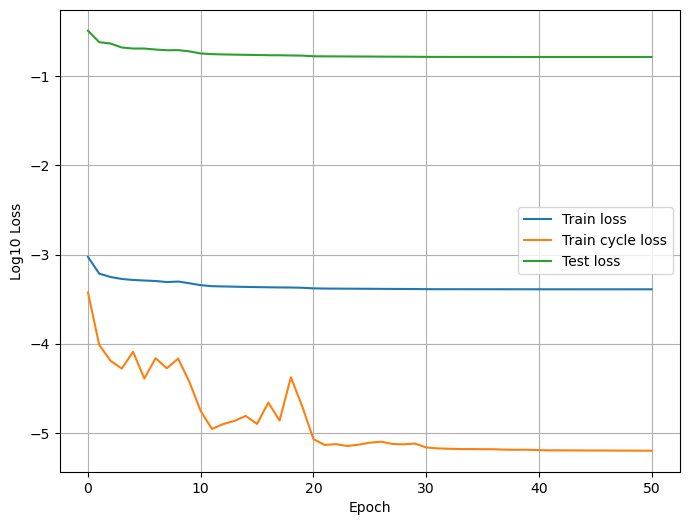

In [ ]:
print(
    f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \t"
    f"Train loss {train_loss/configs['num_train']:.4e} \t"
    f"Train cycle loss {train_cycle_loss/configs['num_train']:.4e} \t"
    f"- Test loss {test_loss:.4e} \t"
    f"- Test Error {relative_error:.2f}% \t"
    f"- Median Test Error {torch.median(median_error).item():.4f}% \t"
    f"- lambda_cycle {lambda_cycle:.2e}"
    )
plt.figure(figsize=(8,6))
plt.plot([np.log10(x) for x in train_loss_hist], label='Train loss')
plt.plot([np.log10(x) for x in train_cycle_loss_hist], label='Train cycle loss')
plt.plot([np.log10(x) for x in test_loss_hist], label='Test loss')
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('Epoch')
plt.ylabel('Log10 Loss')
plt.legend()
plt.grid()


## 2. Coastal inverse: amplitude-weighted loss + CAGrad

Same inverse task restricted to the `coastal` (sinner) ensemble, whose ice signal is
concentrated near the margin, so both the data loss and the cycle loss are
amplitude-weighted (points with large target ice change count 100x more). Inputs are
normalised with the pooled triple statistics and split by a seed-42 `randperm(10000)`
into 8k train / 2k test; the cycle term goes through the frozen *triple* forward
surrogate. Training runs from scratch for 501 epochs: the data loss alone for the first
100, then the cycle gradient merged in with CAGrad (c = 0.2) under a linear 1/400 weight
ramp, the optimiser and LR schedule restarting at that boundary. Test relative L1 reaches
33.0% (best 32.78%) with 3.1% cycle error on the normalised inputs, in about 2.4 h on one
GPU (9 s per epoch before the cycle term is switched on, 19 s after).

Source: `cloud_notebooks/CAGrad_test.ipynb`.

In [ ]:
from src.losses import AmplitudeWeightedLoss
from src.grad_surgery import _cagrad_two_task, _match_param_dtype


In [ ]:
from torch.utils.data import TensorDataset
    

def getDataloaders (configs):
    """
    Loads the required data for the Airfoil experiment and returns the train and test dataloaders.

    Returns:
        train_loader (torch.utils.data.DataLoader): train dataloader
        test_loader (torch.utils.data.DataLoader): test dataloader
    """
    paths = [configs['datapath'] + 'no_smooth/512gp_single_SSH_altimetry_full.pt',
         configs['datapath'] + 'no_smooth/512gp_multi_SSH_altimetry_full.pt',
         configs['datapath'] + 'no_smooth/512gp_single_sinner_SSH_altimetry_full_i1new.pt']#
    paths_used = [configs['datapath'] + 'no_smooth/512gp_single_sinner_SSH_altimetry_full_i1new.pt']
    data_list = [torch.load(path_) for path_ in paths]
    data_list_used = [torch.load(path_) for path_ in paths_used]
    

    outputs = torch.cat([data_["sample_sum"].float().unsqueeze(-1) for data_ in data_list_used], dim=0)  # [N_total, 1]
    inputs_full = torch.cat([data_["altimetry"].float().unsqueeze(-1) for data_ in data_list], dim=0)  # [N_total, M, 1]
    inputs = torch.cat([data_["altimetry"].float().unsqueeze(-1) for data_ in data_list_used], dim=0)  # [N_total, 1]
    # inputs_mean, input_std = -0.0002, 0.0035
    #normalization
    inputs = (inputs - inputs_full.mean())/(inputs_full.std()+1e-6)
    
    
    # path = configs['datapath']+'gp_2_SSH_altimetry_samples_full.pt'

    # data = torch.load(path)
    # inputs = data["altimetry"].float().unsqueeze(-1)
    
    # outputs = data["sample_sum"].float().unsqueeze(-1)
    # outputs = (outputs - outputs.mean())/(outputs.std()+1e-6)#make it worse
    
    #random permutation
    num_total = inputs.shape[0]
    
    g = torch.Generator()
    g.manual_seed(42)
    indices = torch.randperm(num_total, generator=g)


    train_indices = indices[:configs['num_train']]
    test_indices = indices[configs['num_train']:configs['num_train'] + configs['num_test']]
    train_in = inputs[train_indices]
    train_out = outputs[train_indices]
    test_in = inputs[test_indices]
    test_out = outputs[test_indices]
    
    # train_in = inputs[:configs['num_train']]
    # train_out = outputs[:configs['num_train']]
    # test_in = inputs[configs['num_train']:configs['num_train']+configs['num_test']]
    # test_out = outputs[configs['num_train']:configs['num_train']+configs['num_test']]
    # # test_in = inputs[-configs['num_test']:]
    # # test_out = outputs[-configs['num_test']:]


    train_loader = torch.utils.data.DataLoader(TensorDataset(train_in, train_out), batch_size=configs['batch_size'], shuffle=True)
    test_loader = torch.utils.data.DataLoader(TensorDataset(test_in, test_out), batch_size=1, shuffle=False)

    point_data_path = configs['datapath']+'512scaled_display_coords_full.pt'
    point_data = torch.load(point_data_path)
    point_data_in = point_data["Dist"].float()
    point_data_out = point_data["Gr"].float()
    
    return train_loader, test_loader, point_data_in, point_data_out


In [ ]:
device = get_device()        # cuda on the cluster, mps/cpu on a laptop
set_default_device(device)   # the VFT matrices are built on this device

forward_model = torch.load(f"_Models/no_smooth_triple_i1new_forward_full.pt",weights_only = False).to(device)
forward_model.eval() 
for param in forward_model.parameters():
    param.requires_grad = False  # freeze parameters

Model = FNO_dse


In [ ]:
configs = {
    'save_model':           True,
    'model':                'fno-dse',
    'experiment':           'fingerprint',
    'num_train':            8000,
    'num_test':             2000,
    'batch_size':           200, 
    'epochs':               501,
    'test_epochs':          10,

    'datapath':             "data/",  # Path to data!!!!!

    # Training specific parameters
    'learning_rate':        0.001,
    'scheduler_step':       100,
    'scheduler_gamma':      0.1,
    'weight_decay':         1e-4,                   # Weight decay
    'loss_fn':              'L1',                   # Loss function to use - L1, L2
    'loss_fn_test':         'L1',                   # Loss function to use - L1, L2
    'cycle_weight':         0.1,                    # Weight of cycle consistency loss
    'proj_w0_sequential':   False,                  # bare nn.Linear proj_w0 (checkpoint keys proj_w0.*)
    # Model specific parameters
    'modes1':               20,                     # Number of x-modes to use in the Fourier layer
    'modes2':               20,                     # Number of y-modes to use in the Fourier layer
    'width':                32,                     # Number of channels in the convolutional layers
}


start_time = time.time()
print(f'Loading and processing data.')

train_loader, test_loader, configs['point_data_in'],configs['point_data_out'] = getDataloaders(configs)

configs['denormalizer'] = None if not hasattr(train_loader, "denormalizer") else train_loader.denormalizer

print(f'Processing finished in {time.time()-start_time:.2f}s.')


#######
# model
#######
# initialize model
model = Model(configs).to(device)

# TODO: Trainable parameters will now include IPHI parameters as well.
print(f"Number of trainable parameters: {count_params(model)}")
optimizer = Adam(model.parameters(), lr=configs['learning_rate'], weight_decay=configs['weight_decay'])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=configs['scheduler_step'], gamma=configs['scheduler_gamma'])
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max = 30)
# Define the loss function
# if configs['loss_fn'] == 'L1':
#     loss_fn = torch.nn.L1Loss()
# elif configs['loss_fn'] == 'L2':
#     loss_fn = torch.nn.MSELoss('mean')
# else:
#     raise ValueError('Loss function not recognized.')
if configs['loss_fn'] == 'L1':
    loss_fn = AmplitudeWeightedLoss(
        base_loss="L1",
        min_weight=1,
        normalize_weight=False,
    )
elif configs['loss_fn'] == 'L2':
    loss_fn = AmplitudeWeightedLoss(
        base_loss="L2",
        min_weight=1,
        normalize_weight=False,
    )
else:
    raise ValueError('Loss function not recognized.')


# Define the loss function
if configs['loss_fn_test'] == 'L1':
    loss_fn_test = torch.nn.L1Loss()
elif configs['loss_fn_test'] == 'L2':
    loss_fn_test = torch.nn.MSELoss('mean')
else:
    raise ValueError('Loss function test not recognized.')
# class L1WithMeanLoss(nn.Module):
#     def __init__(self, mean_weight=1.0):
#         super().__init__()
#         self.l1 = nn.L1Loss()
#         self.mean_weight = mean_weight

#     def forward(self, pred, target):
#         l1_loss = self.l1(pred, target)
#         mean_loss = torch.abs(pred.mean() - target.mean())
#         return l1_loss + self.mean_weight * mean_loss
# if configs['loss_fn'] == 'L1':
#     loss_fn = L1WithMeanLoss(mean_weight=1)


Loading and processing data.


Processing finished in 1.18s.
Number of trainable parameters: 21949597


In [ ]:
#CAGrad + weight balance
import torch.autograd as autograd
import numpy as np
from scipy.optimize import minimize_scalar

prescribed_cycle_weight = 1/400
epoch_start = 100

##########
# training
##########
training_times = []
train_loss_hist = []
test_loss_hist = []
train_cycle_loss_hist = []
relative_error_hist = []
relative_median_error_hist = []
test_cycle_error_hist = []
test_cycle_median_error_hist = []
lambda_cycle = configs['cycle_weight']

# per-epoch record, consumed by the plots in the next cell
history = {k: [] for k in ('epoch', 'time_s', 'lr', 'train_loss', 'train_cycle_loss',
                           'test_loss', 'test_err', 'med_test_err', 'test_cycle_err',
                           'med_test_cycle_err', 'lambda_cycle')}

# CAGrad parameter (default if not provided)
cagrad_c = configs.get('cagrad_c', 0.2)

for epoch in range(configs['epochs']):
    if epoch == epoch_start:
        # the CAGrad stage restarts the optimiser and the LR schedule
        optimizer = Adam(model.parameters(), lr=configs['learning_rate'], weight_decay=configs['weight_decay'])
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=configs['scheduler_step'], gamma=configs['scheduler_gamma'])

    start_train = time.time()
    train_loss = 0
    train_cycle_loss = 0
    model.train()
    for inputs, targets in train_loader:
        batch_size = targets.shape[0]
        if isinstance(inputs, list):
            inputs = [x.to(device) for x in inputs]
        else:
            inputs = inputs.to(device)
        targets = targets.to(device)

        predictions = model(inputs)

        # Compute loss separate for complex numbers
        if predictions.is_complex():
            loss_inv = (
                loss_fn(predictions.real.view(batch_size, -1), targets.real.view(batch_size, -1)) 
                + loss_fn(predictions.imag.view(batch_size, -1), targets.imag.view(batch_size, -1))
            )
        else:
            loss_inv = loss_fn(predictions.view(batch_size, -1), targets.view(batch_size, -1))

        
        # # For diffeomorphisms, additional loss term:
        # if hasattr(model, "model_iphi") and ('iphi_loss_reg' in configs) and (configs['iphi_loss_reg'] > 0):
        #     samples_x = torch.rand(batch_size, targets.shape[1], 2).cuda() * 3 - 1 # TODO Hardcoded values, check if applies to all
        #     samples_xi = model.model_iphi(samples_x)
        #     loss += configs['iphi_loss_reg'] * loss_fn(samples_xi, samples_x)


        train_loss += loss_inv.item()
        
        #cycle consistency loss
        cycle_outputs = forward_model(predictions)
        loss_cycle = loss_fn(cycle_outputs.view(batch_size, -1), inputs.view(batch_size, -1))

        
        train_cycle_loss += loss_cycle.item()
        
        optimizer.zero_grad()

        params = list(model.parameters())

        grads_inv = autograd.grad(loss_inv, params, retain_graph=True, allow_unused=True)
        grads_inv = [g if g is not None else torch.zeros_like(p) for g, p in zip(grads_inv, params)]
        grads_inv = _match_param_dtype(grads_inv, params)

        if epoch>=epoch_start:
            grads_cycle = autograd.grad(loss_cycle, params, retain_graph=False, allow_unused=True)
            grads_cycle = [g if g is not None else torch.zeros_like(p) for g, p in zip(grads_cycle, params)]
            grads_cycle = _match_param_dtype(grads_cycle, params)
    
            norm_inv = torch.norm(torch.stack([g.norm() for g in grads_inv]))
            norm_cycle = torch.norm(torch.stack([g.norm() for g in grads_cycle]))
            lambda_cycle = (norm_inv / (norm_cycle + 1e-6)).detach()*min(prescribed_cycle_weight*(epoch-epoch_start+1),1)

            # CAGrad combination (2-task)
            grads_cycle_scaled = [lambda_cycle * g for g in grads_cycle]
            projected_grads = _cagrad_two_task(grads_inv, grads_cycle_scaled, c=cagrad_c, eps=1e-12)
            projected_grads = _match_param_dtype(projected_grads, params)
        else:
            projected_grads = grads_inv
            lambda_cycle = 0
                
        # # Weight balancing (automatic)
        # if epoch>=100:
        #     norm_inv = torch.norm(torch.stack([g.norm() for g in grads_inv]))
        #     norm_cycle = torch.norm(torch.stack([g.norm() for g in grads_cycle]))
        #     lambda_cycle = (norm_inv / (norm_cycle + 1e-4)).detach() * 0.1

        #     # PCGrad projection
        #     projected_grads = []
        #     for g1, g2 in zip(grads_inv, grads_cycle):
        #         dot = torch.dot(g1.flatten(), g2.flatten()).real
        #         if dot < 0:
        #             g2_proj = g2 - (dot / (g1.norm()**2 + 1e-4)) * g1
        #         else:
        #             g2_proj = g2
        #         projected_grads.append(g1 + lambda_cycle * g2_proj)
        # else:
        #     projected_grads = grads_inv
        
        # Apply gradients manually
        for p, g in zip(params, projected_grads):
            if p.grad is not None:
                p.grad.detach_()
            p.grad = g

        optimizer.step()
        

    train_loss /= configs['num_train']
    train_cycle_loss /= configs['num_train']
    stop_train = time.time()
    training_times.append(stop_train-start_train)

    scheduler.step()

    ### Only test every test_epochs epochs.
    if epoch % configs['test_epochs'] > 0:
        continue

    ##########
    # testing
    ##########
    with torch.no_grad():
        test_loss = 0
        relative_error = 0
        median_error = torch.zeros(configs['num_test'])

        test_cycle_error = 0
        test_cycle_median_error = torch.zeros(configs['num_test'])

        model.eval()
        for idx, (inputs, targets) in enumerate(test_loader):
            batch_size = targets.shape[0]
            if isinstance(inputs, list):
                inputs = [x.to(device) for x in inputs]
            else:
                inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)

            # + test cycle consistency metrics (percentage)
            cycle_outputs_test = forward_model(predictions)

            # # For different growth factors and sparse data in Humidity, we only consider a small domain.
            # if configs['experiment'] == 'Humidity' and configs['growth'] != 1.0:
            #     l, r, b, t = test_loader.crop
            #     predictions = predictions[:, b:t, l:r,:]
            #     targets = targets[:, b:t, l:r,:]

            # Compute loss separate for complex numbers
            if predictions.is_complex():
                loss = (
                    loss_fn_test(predictions.real.reshape(batch_size, -1), targets.real.reshape(batch_size, -1)) 
                    + loss_fn_test(predictions.imag.reshape(batch_size, -1), targets.imag.reshape(batch_size, -1))
                )
                # For metrics we only consider REAL parts
                predictions = predictions.real
                targets = targets.real

                # + cycle metrics also on REAL parts
                cycle_outputs_test = cycle_outputs_test.real
                inputs_metric = inputs.real if (not isinstance(inputs, list) and inputs.is_complex()) else inputs
            else:
                loss = loss_fn_test(predictions.reshape(batch_size, -1), targets.reshape(batch_size, -1))

                # + cycle metrics on real tensors
                inputs_metric = inputs

            test_loss += loss.item()

            relative_error += percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))
            median_error[idx] = percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))

            # + cycle percentage error
            test_cycle_error += percentage_difference(inputs_metric.reshape(batch_size, -1), cycle_outputs_test.reshape(batch_size, -1))
            test_cycle_median_error[idx] = percentage_difference(inputs_metric.reshape(batch_size, -1), cycle_outputs_test.reshape(batch_size, -1))

    test_loss /= configs['num_test']
    relative_error /= configs['num_test']
    relative_error_hist.append(relative_error)
    relative_median_error_hist.append(torch.median(median_error))

    test_cycle_error /= configs['num_test']
    test_cycle_error_hist.append(test_cycle_error)
    test_cycle_median_error_hist.append(torch.median(test_cycle_median_error))

    print(
    f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \t"
    f"Train loss {train_loss:.4e} \t"
    f"Train cycle loss {train_cycle_loss:.4e} \t"
    f"- Test loss {test_loss:.4e} \t"
    f"- Test Error {relative_error:.2f}% \t"
    f"- Median Test Error {torch.median(median_error).item():.4f}% \t"
    f"- Test Cycle Error {test_cycle_error:.2f}% \t"
    f"- Median Test Cycle Error {torch.median(test_cycle_median_error).item():.4f}% \t"
    f"- lambda_cycle {lambda_cycle:.2e}"
    )
    train_loss_hist.append(train_loss)
    train_cycle_loss_hist.append(train_cycle_loss)
    test_loss_hist.append(test_loss)

    history['epoch'].append(epoch)
    history['time_s'].append(stop_train - start_train)
    history['lr'].append(scheduler.get_last_lr()[0])
    history['train_loss'].append(train_loss)
    history['train_cycle_loss'].append(train_cycle_loss)
    history['test_loss'].append(test_loss)
    history['test_err'].append(relative_error)
    history['med_test_err'].append(torch.median(median_error).item())
    history['test_cycle_err'].append(test_cycle_error)
    history['med_test_cycle_err'].append(torch.median(test_cycle_median_error).item())
    history['lambda_cycle'].append(float(lambda_cycle))

    if relative_error == min(relative_error_hist):
        best_model = copy.deepcopy(model)
    if test_cycle_error == min(test_cycle_error_hist):
        best_cycle_model = copy.deepcopy(model)

lowest_error = min(relative_error_hist)
# Plot losses
plt.figure(figsize=(8,6))
plt.plot([np.log(x) for x in train_loss_hist], label='Train loss')
plt.plot([np.log(x) for x in test_loss_hist], label='Test loss')
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid()
# plt.savefig(f"_Models/loss_history.png")
plt.close()

# Save Model
if configs['save_model']:
    # Remove unnecessary data from models
    best_model.point_data = None
    best_model.denormalizer = None
    print(f"Experiment: {configs['experiment']} \t- Model: {configs['model']} \t- Error: {lowest_error:.4f}%")
    torch.save(best_model, f"_Models/{configs['experiment']}_{configs['model']}.pt")
torch.save(best_model, f"_Models/_no_smooth_512inverse_sinner_cycle_full_i1new_.pt")
torch.save(best_cycle_model, f"_Models/_no_smooth_512inverse_sinner_cycle_full_i1new_bestcycle_.pt")
np.savez("_no_smooth_512full_sinner_inverse_cycle_fingerprint_FNO_dse_history_i1new_.npz",
         training_times=training_times,
         train_loss_hist=train_loss_hist,
         train_cycle_loss_hist=train_cycle_loss_hist,
         test_loss_hist=test_loss_hist,
         relative_error_hist=relative_error_hist,
         relative_median_error_hist=relative_median_error_hist,
         test_cycle_error_hist=test_cycle_error_hist,
         test_cycle_median_error_hist=test_cycle_median_error_hist)


Epoch [000/500] in 9.31s with LR 1.00e-03: 	Train loss 4.6584e-02 	Train cycle loss 4.8741e-02 	- Test loss 7.9594e-02 	- Test Error 68.98% 	- Median Test Error 70.7496% 	- Test Cycle Error 63.16% 	- Median Test Cycle Error 45.5442% 	- lambda_cycle 0.00e+00
Epoch [010/500] in 9.05s with LR 1.00e-03: 	Train loss 3.3522e-02 	Train cycle loss 3.2097e-02 	- Test loss 6.5176e-02 	- Test Error 56.72% 	- Median Test Error 56.4765% 	- Test Cycle Error 60.01% 	- Median Test Cycle Error 44.8096% 	- lambda_cycle 0.00e+00
Epoch [020/500] in 9.07s with LR 1.00e-03: 	Train loss 3.1228e-02 	Train cycle loss 2.6352e-02 	- Test loss 6.2743e-02 	- Test Error 54.55% 	- Median Test Error 54.7635% 	- Test Cycle Error 51.27% 	- Median Test Cycle Error 37.8053% 	- lambda_cycle 0.00e+00
Epoch [030/500] in 9.07s with LR 1.00e-03: 	Train loss 3.0346e-02 	Train cycle loss 2.4189e-02 	- Test loss 5.9388e-02 	- Test Error 51.62% 	- Median Test Error 51.8117% 	- Test Cycle Error 44.98% 	- Median Test Cycle Error 33

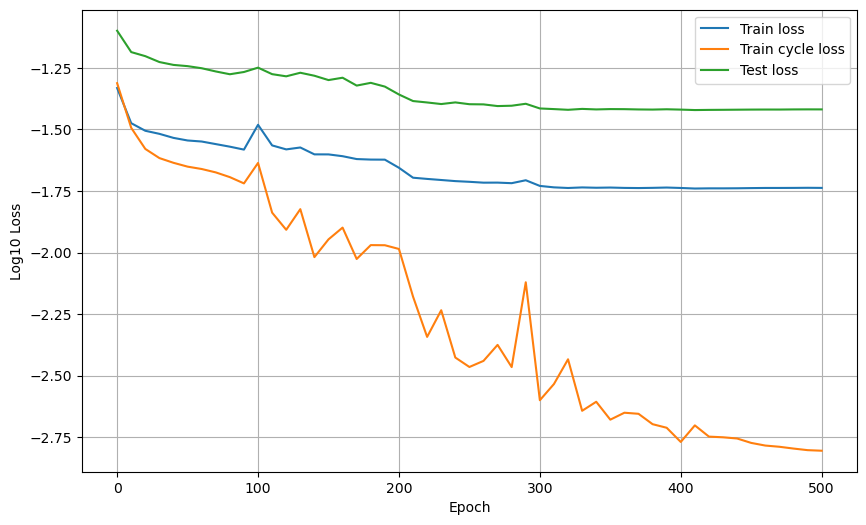

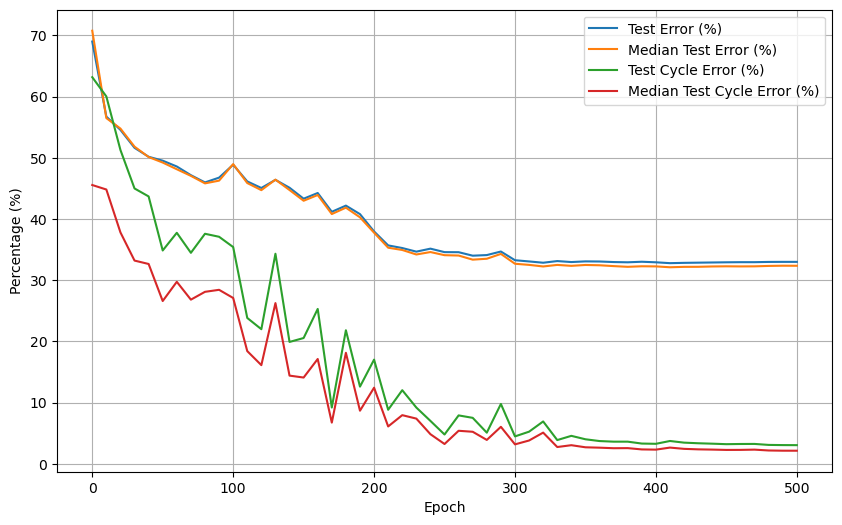

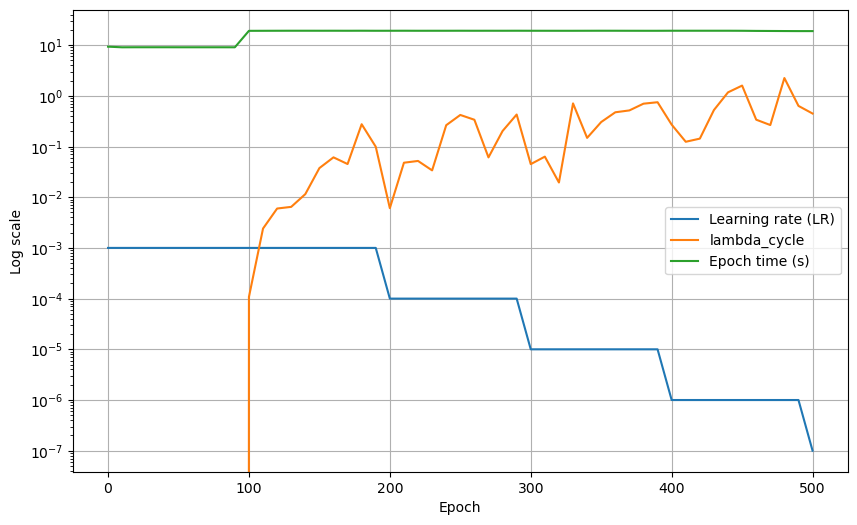

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.array(history['epoch'], dtype=int)
times_s = np.array(history['time_s'], dtype=float)
lrs = np.array(history['lr'], dtype=float)
train_loss = np.array(history['train_loss'], dtype=float)
train_cycle_loss = np.array(history['train_cycle_loss'], dtype=float)
test_loss = np.array(history['test_loss'], dtype=float)
test_err = np.array(history['test_err'], dtype=float)
med_test_err = np.array(history['med_test_err'], dtype=float)
test_cycle_err = np.array(history['test_cycle_err'], dtype=float)
med_test_cycle_err = np.array(history['med_test_cycle_err'], dtype=float)
lambda_cycle = np.array(history['lambda_cycle'], dtype=float)

# ----------------------------
# Plot 1: loss terms
# ----------------------------
plt.figure(figsize=(10,6))
plt.plot(epochs, np.log10(train_loss), label="Train loss")
plt.plot(epochs, np.log10(train_cycle_loss), label="Train cycle loss")
plt.plot(epochs, np.log10(test_loss), label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Log10 Loss")
plt.legend()
plt.grid()

# ----------------------------
# Plot 2: relative/percentage error terms
# ----------------------------
plt.figure(figsize=(10,6))
plt.plot(epochs, test_err, label="Test Error (%)")
plt.plot(epochs, med_test_err, label="Median Test Error (%)")
plt.plot(epochs, test_cycle_err, label="Test Cycle Error (%)")
plt.plot(epochs, med_test_cycle_err, label="Median Test Cycle Error (%)")
plt.xlabel("Epoch")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid()

# ----------------------------
# Plot 3: auxiliary indicators (lr, lambda, time)
# ----------------------------
plt.figure(figsize=(10,6))
plt.plot(epochs, lrs, label="Learning rate (LR)")
plt.plot(epochs, lambda_cycle, label="lambda_cycle")
plt.plot(epochs, times_s, label="Epoch time (s)")
plt.yscale("log")  # LR and lambda span orders of magnitude; time stays readable
plt.xlabel("Epoch")
plt.ylabel("Log scale")
plt.legend()
plt.grid()
